# 1. Import

In [ ]:
# --- plot_revision setup ---
import sys
from pathlib import Path
_HERE = Path.cwd().resolve()
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR, RESULT_HUMAN_DIR, RESULT_MOUSE_DIR, RESULT_MULTI_DIR,
    SPC_MULTI_CSV, CLAUDE_CLADE_DIR, TREE_NWK,
    RESULT_RETRIEVAL_DIR, GAP_HUMAN_CSV, GAP_MOUSE_CSV,
    CKPT_ROOT, EPI_EVO2HIC_DIR, PRETRAIN_CKPT_DIR, PRETRAIN_CKPT,
    SR_EVO2HIC_HUMAN_DIR, SEQ2HIC_CKPT,
    HIC_DATA_ROOT, HIC_RAW_DIR, HIC_RAW, DNA_FASTA, MOTIF_MEME,
    EVO2_EMB_HUMAN, EVO2_EMB_MOUSE, TRACKS_GM12878_CHR10_NPY,
    ORCA_MALLPREDS_PTH, ORCA_EXPECTED_NPY,
    MOTIF_STATS_CSV,
    HUMAN_MERGED_CSV, HUMAN_INTER_DIR,
    HIC2TRACK_DIR, HIC2TRACK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


In [ ]:

# This source code is licensed under the license found in the
# LICENSE file in the root directory of this source tree.
# --------------------------------------------------------
# References:
# Sagittarius to https://github.com/addiewc/Sagittarius
# --------------------------------------------------------
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import seaborn as sns
from plot_settings import colors as candidate_colors
from plot_utils import plot_box_with_points, clear_test_log, dump_test_log

import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-white')


[]

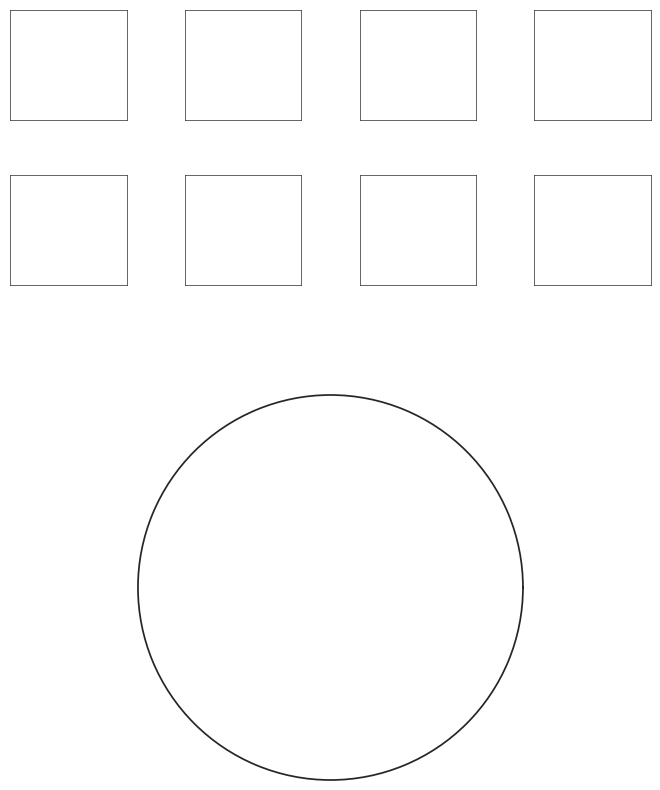

In [2]:
fig = plt.figure(figsize=(8.27, 10))

# 定义 GridSpec
# 前两行 4 列，第三行 1 列
gs = gridspec.GridSpec(
    5, 4,
    figure=fig,
    height_ratios=[2, 1, 2, 2, 7],  # 可以调整最后一行更高一些
    hspace=0, wspace=0.5
)

# 前两行各4个子图
axes_top = []
for i in [0,2]:  # 行
    row_axes = []
    for j in range(4):  # 列
        ax = fig.add_subplot(gs[i, j])
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
        row_axes.append(ax)
    axes_top.append(row_axes)


# 第三行单独一个大图，占据4列
ax_bottom = fig.add_subplot(gs[4, :], projection='polar')
ax_bottom.set_xticks([]); ax_bottom.set_yticks([])


In [3]:
import matplotlib as mpl
plt.rcParams.update({'font.size': 8})
print("xtick.labelsize:", mpl.rcParams['xtick.labelsize'])
print("ytick.labelsize:", mpl.rcParams['ytick.labelsize'])
print("axes.labelsize:", mpl.rcParams['axes.labelsize'])
print("axes.titlesize:", mpl.rcParams['axes.titlesize'])
print("legend.fontsize:", mpl.rcParams['legend.fontsize'])


xtick.labelsize: medium
ytick.labelsize: medium
axes.labelsize: medium
axes.titlesize: large
legend.fontsize: medium


In [4]:
color_maps = {
    'Evo2HiC' : candidate_colors[0],
    'HiCARN2' : candidate_colors[1],
    'HiCARN1' : candidate_colors[2],
    'HiCNN' : candidate_colors[3]
}

# 2. Human

In [ ]:


clear_test_log()
methods = ['Evo2HiC', 'HiCARN2', 'HiCARN1', 'HiCNN']

# Metric: MSE
colors = [color_maps[n] for n in methods]
NUM=len(methods)

results = pd.read_csv(str(RESULT_HUMAN_DIR / 'PCC.csv'), sep='\t')

plot_box_with_points(axes_top[0][0], results, methods, colors=colors, ylabel='PCC', point_size=2, sig_pair = ('Evo2HiC', 'HiCARN2'), yticks_num=2, log_panel='Fig6a_Human', log_metric='PCC')

results = pd.read_csv(str(RESULT_HUMAN_DIR / 'SPC.csv'), sep='\t')

plot_box_with_points(axes_top[0][1], results, methods, colors=colors, ylabel='SPC',point_size=2, sig_pair = ('Evo2HiC', 'HiCARN2'), yticks_num=2, log_panel='Fig6a_Human', log_metric='SPC')

results = pd.read_csv(str(RESULT_HUMAN_DIR / 'PSNR.csv'), sep='\t')

plot_box_with_points(axes_top[0][2], results, methods, colors=colors, ylabel='PSNR',point_size=2, sig_pair = ('Evo2HiC', 'HiCARN2'), yticks_num=2, log_panel='Fig6a_Human', log_metric='PSNR')

results = pd.read_csv(str(RESULT_HUMAN_DIR / 'SSIM.csv'), sep='\t')

plot_box_with_points(axes_top[0][3], results, methods, colors=colors, ylabel='SSIM',point_size=2, sig_pair = ('Evo2HiC', 'HiCARN2'), yticks_num=2, log_panel='Fig6a_Human', log_metric='SSIM')

row = 0  # 想加标题的行
axs_row = axes_top[row]  # 这一行的所有子图

# 计算该行最左和最右子图的位置
bbox_left = axs_row[0].get_position()
bbox_right = axs_row[-1].get_position()

# 计算该行的水平中心和顶部位置
center_x = (bbox_left.x0 + bbox_right.x1) / 2
top_y = max(ax.get_position().y1 for ax in axs_row)

# 在这一行上方加一个“局部 suptitle”
fig.text(center_x, top_y + 0.01, "Human", ha='center', va='bottom',
         fontsize=12)

fig

# 3. Mouse

In [ ]:


methods = ['Evo2HiC', 'HiCARN2', 'HiCARN1']

# Metric: MSE
colors = [color_maps[n] for n in methods]
NUM=len(methods)

results = pd.read_csv(str(RESULT_MOUSE_DIR / 'PCC.csv'), sep='\t')

plot_box_with_points(axes_top[1][0], results, methods, colors=colors, ylabel='PCC', point_size=2, sig_pair = ('Evo2HiC', 'HiCARN2'), yticks_num=2, log_panel='Fig6b_Mouse', log_metric='PCC')

results = pd.read_csv(str(RESULT_MOUSE_DIR / 'SPC.csv'), sep='\t')

plot_box_with_points(axes_top[1][1], results, methods, colors=colors, ylabel='SPC',point_size=2, sig_pair = ('Evo2HiC', 'HiCARN2'), yticks_num=2, log_panel='Fig6b_Mouse', log_metric='SPC')

results = pd.read_csv(str(RESULT_MOUSE_DIR / 'PSNR.csv'), sep='\t')

plot_box_with_points(axes_top[1][2], results, methods, colors=colors, ylabel='PSNR',point_size=2, sig_pair = ('Evo2HiC', 'HiCARN2'), yticks_num=2, log_panel='Fig6b_Mouse', log_metric='PSNR')

results = pd.read_csv(str(RESULT_MOUSE_DIR / 'SSIM.csv'), sep='\t')

plot_box_with_points(axes_top[1][3], results, methods, colors=colors, ylabel='SSIM',point_size=2, sig_pair = ('Evo2HiC', 'HiCARN2'), yticks_num=2, log_panel='Fig6b_Mouse', log_metric='SSIM')

row = 1  # 想加标题的行
axs_row = axes_top[row]  # 这一行的所有子图

# 计算该行最左和最右子图的位置
bbox_left = axs_row[0].get_position()
bbox_right = axs_row[-1].get_position()

# 计算该行的水平中心和顶部位置
center_x = (bbox_left.x0 + bbox_right.x1) / 2
top_y = max(ax.get_position().y1 for ax in axs_row)

# 在这一行上方加一个“局部 suptitle”
fig.text(center_x, top_y + 0.01, "Mouse", ha='center', va='bottom',
         fontsize=12)


fig

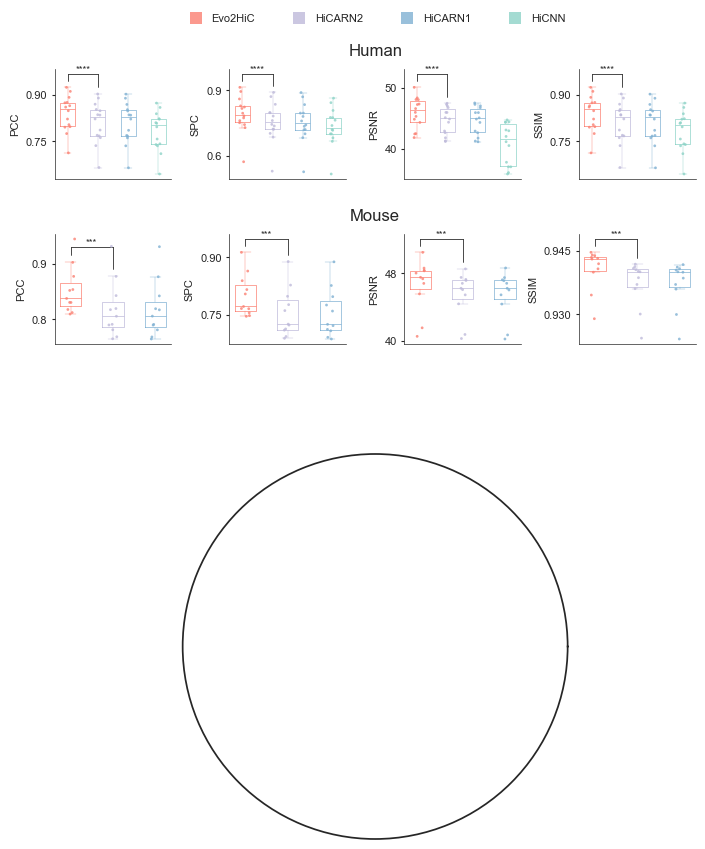

In [7]:
pos0, pos1 = axes_top[0][0].get_position(), axes_top[0][3].get_position()
x = (pos0.x0+pos1.x1)/2
y = pos0.y1 + 0.05

labels = ['Evo2HiC', 'HiCARN2', 'HiCARN1', 'HiCNN']

# 删除旧 legend（防止重复）
if hasattr(fig, "legend_") and fig.legend_ is not None:
    fig.legend_.remove()

handles = [Line2D([0],[0], marker='s', linestyle='', markersize=8,
                markerfacecolor=color_maps[m], markeredgewidth=0, alpha=0.8,
                label=m) for i, m in enumerate(labels)]

# 在左上角单独放 legend
fig.legend(
    handles, labels,
    loc='center',
    bbox_to_anchor=(x, y),  # 锚点设在左上角稍上方
    ncol=len(labels),
    frameon=False,
    fontsize=8,           # 字体更小
    handletextpad=0.4,    # 图例符号与文字间距
    columnspacing=3,    # 各列间距
    borderaxespad=0.1     # 与轴的边界间距
)
fig

# 4. DNA zoo

177
176
155
155


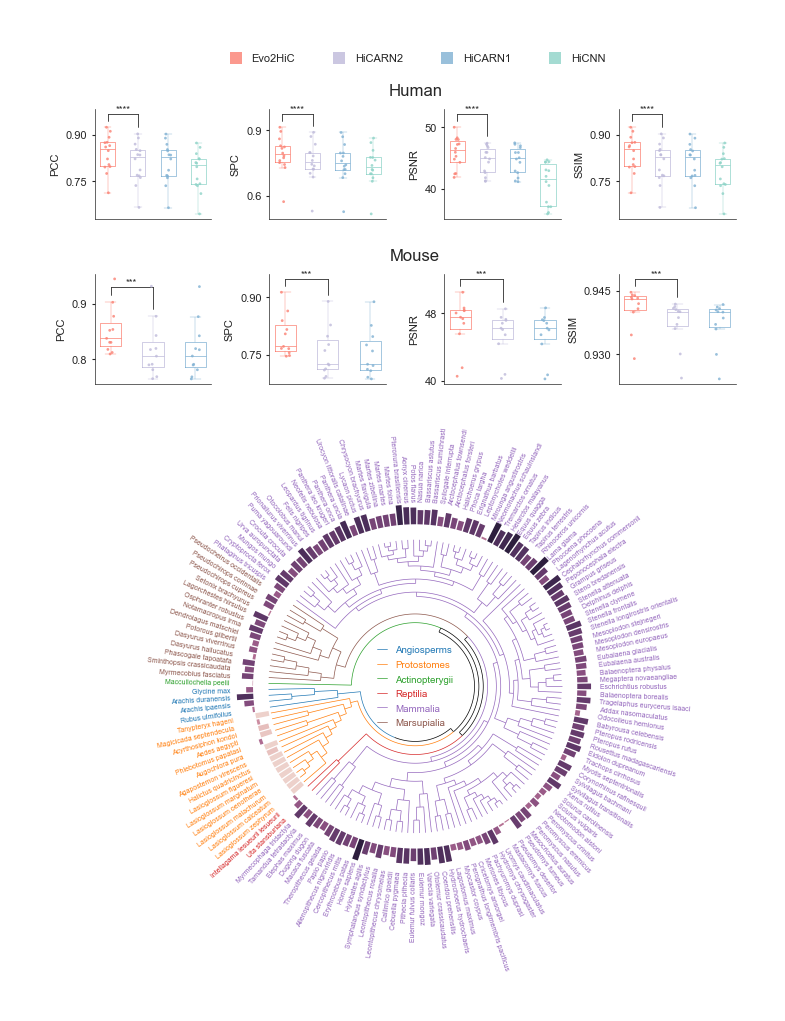

In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd
import seaborn as sns
import pickle
import numpy as np

ax_bottom.clear()

methods = ['EvoHiC', 'HiCARN2']

def name_mapping(species):
    synonym = {
        'Herpailurus_yagouaroundi' : 'Puma_yagouaroundi',
        'Eulemur_collaris' : 'Eulemur_fulvus_collaris',
    }
    if species in synonym:
        return synonym[species]

    if '__' in species:
        return species.split('__')[0]

    return species
    

result = pd.read_csv(str(SPC_MULTI_CSV), sep='\t')
species_list = [name_mapping(s) for s in result['species'].tolist()]
improve = (result[methods[0]] - result[methods[1]]).tolist()
species2improve = dict(zip(species_list, improve))

print(len(result))
print(len(set(species_list)))

from pycirclize import Circos
from collections import defaultdict
from pycirclize.utils import ColorCycler
import math

tree_file = str(TREE_NWK)
circos, tv = Circos.initialize_from_tree(
    tree_file,
    start=-90,
    end=270,
    r_lim=(30, 80),
    leaf_label_rmargin=21,
    leaf_label_size=5,
    ignore_branch_length=True,
    label_formatter=lambda t: t.replace("_", " "),
)

#tv : TreeViz TreeViz instance pycirclize/tree.py
claude_dir = str(CLAUDE_CLADE_DIR) + '/'
claude_name_list=["Angiosperms","Protostomes","Actinopterygii","Reptilia","Mammalia","Marsupialia"]
group_name2species_list=defaultdict(list)

for claude_name in claude_name_list:
    cur_path=claude_dir+f"claude_{claude_name}_clean.txt"
    with open(cur_path,"r") as file:
        for line in file:
            cur_name=line.strip("\n")
            group_name2species_list[claude_name].append(cur_name)

# Set tree line color & label color

S = set(tv.leaf_labels)
ColorCycler.set_cmap("tab10")
group_name2color = {name: ColorCycler() for name in group_name2species_list.keys()}
for group_name, sps in group_name2species_list.items():
    color = group_name2color[group_name]
    S.difference_update(set(sps))
    sps = list(set(sps).intersection(set(tv.leaf_labels)))
    tv.set_node_line_props(sps, color=color, apply_label_color=True)

## add bar
sector = circos.sectors[0]
bar_track = sector.add_track((80,100))
species_list = tv.leaf_labels
height=[]
min_clip = -0.02
for x in species_list:
    if x == 'Homo_sapiens':
        height.append(0.7881 - 0.7547)
        continue
    if x in species2improve:
        cur_val =species2improve[x]
        cur_val=max(min_clip,cur_val)
        height.append(cur_val)
    else:
        height.append(0)

print(len(height))
print(len(species_list))

percentile_98=np.percentile(height,98)
height=np.minimum(height,percentile_98)
start=-90
end=270
rad_list=[]
for k in range(len(species_list)):
    cur_angle= k/len(species_list)*360
    cur_rad=math.radians(start)+math.radians(cur_angle)
    rad_list.append(cur_rad)
rad_list=np.arange(0, int(len(species_list))) + 0.5
my_cmap = sns.cubehelix_palette(as_cmap=True)
rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))
bar_track.bar(rad_list, height, vmin=min_clip-0.003, color=my_cmap(rescale(height)))

# Plot figure & set legend on center
circos.plotfig(ax=ax_bottom)
_ = circos.ax.legend(
    handles=[Line2D([], [], label=n, color=c) for n, c in group_name2color.items()],
    labelcolor=group_name2color.values(),
    fontsize=7,
    loc="center",
    bbox_to_anchor=(0.5, 0.5),
)

fig

In [9]:
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase

# 1) 先画主图，调用 circos.plotfig(...)、tight_layout()/constrained_layout 都在前面完成
# circos.plotfig(ax=ax_bottom)
# fig.tight_layout()   # 如果用，放在这步

# 2) 删除旧的 colorbar 轴（重复运行时很重要）
for a in list(fig.axes):
    if a.get_label() == "spc_cb":
        a.remove()

# 3) 用图级坐标在“圆外右下”加一个小色条
fig.canvas.draw()                       # 让布局结果稳定下来
bbox = ax_bottom.get_position()         # 主极坐标轴在图中的位置
norm = Normalize(vmin=min_clip, vmax=percentile_98)

x0 = bbox.x1 + 0.015   # 右侧再往外一点
y0 = bbox.y0 - 0.025   # 下方悬出去一点
w  = 0.1              # 色条长度（占图宽的比例）
h  = 0.01           # 色条厚度（占图高的比例）

cax = fig.add_axes([x0, y0, w, h], label="spc_cb")
cax.set_clip_on(False)

cbar = ColorbarBase(cax, cmap=my_cmap, norm=norm, orientation='horizontal')
cbar.set_label('SPC absolute improvement', fontsize=8, labelpad=2)
cbar.ax.tick_params(labelsize=7, length=2)
cbar.outline.set_linewidth(0.6)

# 5. Final

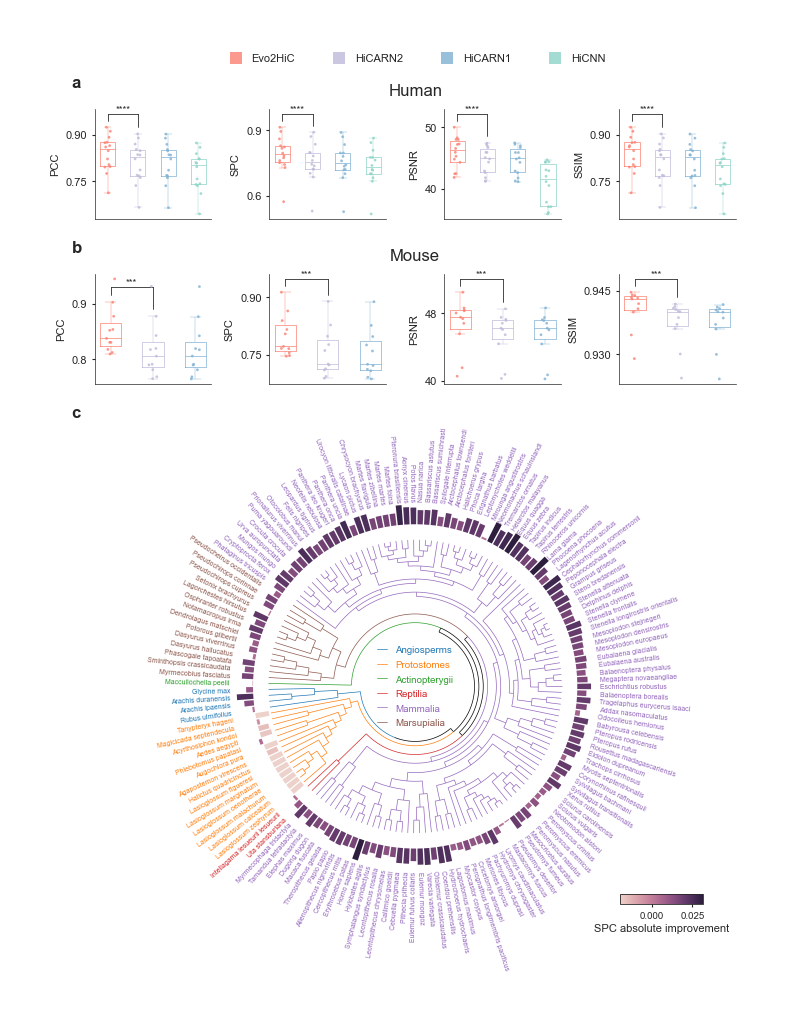

In [10]:
labels = ['a', 'b']

for ax, label in zip([axes_top[0][0], axes_top[1][0]], labels):
    ax.text(
        -0.2, 1.3, f'{label}',           # 相对位置：左上角内一点
        transform=ax.transAxes, 
        fontsize=12,
        fontname='Arial',               # 字体
        fontweight='bold',                  # 粗体 (Nature风格)
        ha='left', va='top'                 # 对齐方式
    )
ax_bottom.text(
    -0.2, -0.2, f'c',           # 相对位置：左上角内一点
    transform=ax.transAxes, 
    fontsize=12,
    fontname='Arial',               # 字体
    fontweight='bold',                  # 粗体 (Nature风格)
    ha='left', va='top'                 # 对齐方式
)
fig

In [11]:
fig.savefig(str(OUT_DIR / 'Fig4.pdf'))

In [ ]:
log_df = dump_test_log('../Figures/Fig4_stats.tsv')
print(log_df.to_string(index=False))